### Original file: [here](/home/links/ct715/eddy_feedback/chapter1/daily_efp/bootstrapped_jet_shifts.ipynb)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xarray as xr
from scipy.stats import pearsonr
from pypalettes import load_cmap
import statsmodels.api as sm

import functions.data_wrangling as dw

# Import data

## Mixed-freq. data

In [21]:
# Import jet shift data (Screen 2022)
jet_responses = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/daily_efp/data/jet_responses_screen2022.csv')

# Import EFP data
og_efp = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/efp_random/data/non-regridded_efp_AWI-fabricated.csv', index_col=0)
og_efp['model'] = og_efp['model'].replace({'ECHAM6.3': 'AWI-CM-1-1-MR'})

# merge datasets
og = pd.merge(jet_responses, og_efp, on='model', how='outer')
og = og.dropna(subset=['efp_sh', 'efp_nh', 'NH_response']).reset_index(drop=True)
og

,model,SH_response,NH_response,efp_nh,efp_sh
0,AWI-CM-1-1-MR,NaN,-0.492325,0.3724,0.4354
1,CESM1-WACCM-SC,-0.030533,-0.445972,0.1297,0.0295
2,CESM2,-0.242725,-0.643093,0.3693,0.3419
3,CNRM-CM6-1,NaN,-0.604725,0.2421,0.2082
4,CanESM5,-0.569641,-0.755676,0.4256,0.4618
5,E3SMv1,-0.040096,-0.223373,0.0543,0.0542
6,FGOALS-f3-L,0.125217,-0.323620,0.2354,0.1274
7,HadGEM3-GC31-LL,-0.246933,-0.430347,0.2730,0.2951
8,HadGEM3-GC31-MM,-0.205715,-0.784420,0.3137,0.3002
9,IPSL-CM6A-LR,-0.132912,-0.450916,0.2719,0.1959


## Daily-mean EFP data

In [22]:
efp_df_all = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/zz_paper_plots/data/daily-efp_colours_PAMIP+JRA55.csv')
efp_df = efp_df_all[efp_df_all['model'] != 'JRA55'].reset_index(drop=True)

efp = pd.merge(jet_responses, efp_df, on='model', how='outer')
efp = efp.dropna(subset=['efp_sh', 'efp_nh']).reset_index(drop=True)
efp

,model,SH_response,NH_response,efp_nh,efp_sh,color,marker
0,AWI-CM-1-1-MR,NaN,-0.492325,0.2592,0.2557,#C969A1FF,o
1,CNRM-CM6-1,NaN,-0.604725,0.2244,0.1944,#CE4441FF,s
2,CanESM5,-0.569641,-0.755676,0.3133,0.3271,#EE8577FF,^
3,FGOALS-f3-L,0.125217,-0.323620,0.2353,0.1273,#EB7926FF,v
4,HadGEM3-GC31-LL,-0.246933,-0.430347,0.1735,0.1729,#FFBB44FF,D
5,HadGEM3-GC31-MM,-0.205715,-0.784420,0.2525,0.1874,#859B6CFF,p
6,IPSL-CM6A-LR,-0.132912,-0.450916,0.2623,0.2015,#62929AFF,h
7,MIROC6,-0.128574,-0.383339,0.1592,0.2058,#004F63FF,P


## JRA55 bootstrapped stats

In [23]:
jra = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/daily_efp/data/JRA55_bootstrapped_reanalysis_stats_1979-2016.csv')

jra_day = jra[jra['Model'] == 'JRA55 (daily)'].reset_index(drop=True)
jra_6h = jra[jra['Model'] == 'JRA55 (6h)'].reset_index(drop=True)

jra

,Model,EFP_NH,EFP_SH,EFP_NH_STD,EFP_SH_STD
0,JRA55 (daily),0.386683,0.226659,0.053830,0.032270
1,JRA55 (6h),0.449022,0.361631,0.055803,0.036637


# Plotting

## Matching models in both rows

In [24]:
og_cut = og[og['model'].isin(efp['model'])].reset_index(drop=True)
og_cut['color'] = efp['color']
og_cut['marker'] = efp['marker']
og_cut

,model,SH_response,NH_response,efp_nh,efp_sh,color,marker
0,AWI-CM-1-1-MR,NaN,-0.492325,0.3724,0.4354,#C969A1FF,o
1,CNRM-CM6-1,NaN,-0.604725,0.2421,0.2082,#CE4441FF,s
2,CanESM5,-0.569641,-0.755676,0.4256,0.4618,#EE8577FF,^
3,FGOALS-f3-L,0.125217,-0.323620,0.2354,0.1274,#EB7926FF,v
4,HadGEM3-GC31-LL,-0.246933,-0.430347,0.2730,0.2951,#FFBB44FF,D
5,HadGEM3-GC31-MM,-0.205715,-0.784420,0.3137,0.3002,#859B6CFF,p
6,IPSL-CM6A-LR,-0.132912,-0.450916,0.2719,0.1959,#62929AFF,h
7,MIROC6,-0.128574,-0.383339,0.2213,0.3253,#004F63FF,P


# Confidence intervals

In [25]:
# Configuration
dfs = [og_cut, efp]
responses = ['SH_response', 'NH_response']
efp_cols = ['efp_sh', 'efp_nh']
titles = [
    'Southern Hemisphere (mixed freq.)', 
    'Northern Hemisphere (mixed freq.)', 
    'Southern Hemisphere (daily-mean)', 
    'Northern Hemisphere (daily-mean)'
]
subplots = ['(a)', '(b)', '(c)', '(d)']

# Create color and marker mappings
color_map = dict(zip(efp_df['model'], efp_df['color']))
marker_map = dict(zip(efp_df['model'], efp_df['marker']))


## Total Least Squares

CIs calculated using bootstrapping

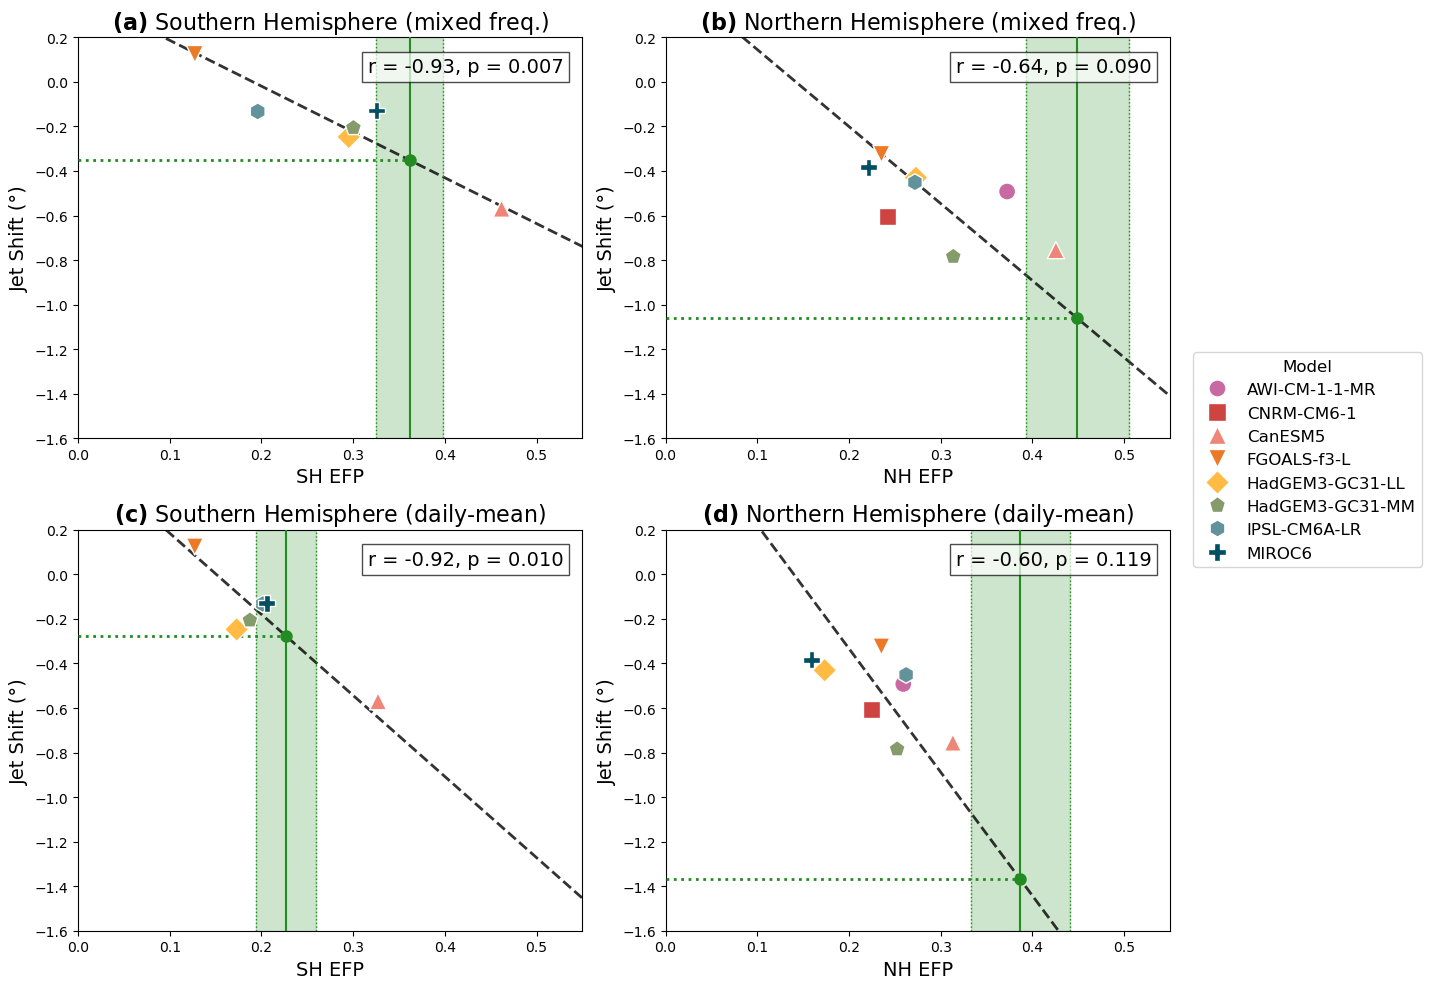

In [ ]:
import numpy as np
import scipy.linalg as la
import seaborn as sns
import matplotlib.pyplot as plt

# Your existing setup
obs_efp = {
    'SH': {
        'mixed': jra.loc[1, 'EFP_SH'],
        'daily': jra.loc[0, 'EFP_SH'],
        'mixed_std': jra.loc[1, 'EFP_SH_STD'],
        'daily_std': jra.loc[0, 'EFP_SH_STD']
    },
    'NH': {
        'mixed': jra.loc[1, 'EFP_NH'],
        'daily': jra.loc[0, 'EFP_NH'],
        'mixed_std': jra.loc[1, 'EFP_NH_STD'],
        'daily_std': jra.loc[0, 'EFP_NH_STD']
    }
}

X_LIM = (0, 0.55)
Y_LIM = (-1.6, 0.2)

model_list = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, df in enumerate(dfs):
    for j, (resp, efp_col) in enumerate(zip(responses, efp_cols)):
        ax_idx = i * 2 + j
        ax = axes[ax_idx]

        # Clean data
        plot_data = df[[efp_col, resp, 'model']].dropna()
        X = plot_data[efp_col].values
        y = plot_data[resp].values

        # --- TLS REGRESSION ---
        # Augment X with a column of ones for the intercept
        X_aug = np.vstack([X, np.ones(len(X))]).T
        # Augment the data matrix with y
        data = np.column_stack([X_aug, y])
        # Perform SVD
        _, _, Vt = la.svd(data, full_matrices=False)
        # Extract the TLS solution
        beta_tls = -Vt[-1, :-1] / Vt[-1, -1]
        beta_0, beta_1 = beta_tls[1], beta_tls[0]

        # Store the model parameters
        model_list.append((beta_0, beta_1))

        # Generate regression line
        x_range = np.linspace(X_LIM[0], X_LIM[1], 100)
        y_range = beta_0 + beta_1 * x_range

        # Plot regression line
        ax.plot(x_range, y_range, 'k--', linewidth=2, alpha=0.8, zorder=2)

        # Scatter plot
        sns.scatterplot(
            data=plot_data,
            x=efp_col,
            y=resp,
            hue='model',
            style='model',
            palette=color_map,
            markers=marker_map,
            s=150,
            ax=ax,
            zorder=4
        )
        handles, labels = ax.get_legend_handles_labels()
        ax.legend_.remove()

        # --- OBSERVED VALUE LINES ---
        hemisphere = 'NH' if j == 1 else 'SH'
        time_res = 'daily' if i == 1 else 'mixed'
        obs_x = obs_efp[hemisphere][time_res]
        obs_std = obs_efp[hemisphere][time_res + '_std']
        obs_y = beta_0 + beta_1 * obs_x

        # Vertical lines and shading
        ax.vlines(obs_x, Y_LIM[0], Y_LIM[1], colors='forestgreen', linewidth=1.5, zorder=3)
        ax.vlines(obs_x - obs_std, Y_LIM[0], Y_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.vlines(obs_x + obs_std, Y_LIM[0], Y_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.axvspan(obs_x - obs_std, obs_x + obs_std, color='green', alpha=0.2, zorder=1)
        ax.hlines(obs_y, X_LIM[0], obs_x, colors='forestgreen', linestyles=':', linewidth=2, zorder=3)
        ax.plot(obs_x, obs_y, color='forestgreen', marker='o', markersize=8, zorder=5)

        # Correlation annotation
        dw.add_correlation(ax, plot_data[efp_col], plot_data[resp], x_loc=0.575)

        # Labels and limits
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_title(f'$\\bf{{{subplots[ax_idx]}}}$ {titles[ax_idx]}', fontsize=16)
        ax.set_ylabel('Jet Shift (°)', fontsize=14)
        if ax_idx in [1, 3]:
            ax.set_xlabel('NH EFP', fontsize=14)
        else:
            ax.set_xlabel('SH EFP', fontsize=14)

# Shared legend
fig.legend(
    handles,
    efp_df['model'],
    title='Model',
    bbox_to_anchor=(0.85, 0.65),
    loc='upper left',
    fontsize=12,
    title_fontsize=12
)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### Confidence intervals on TLS regression line

In [27]:
# ==============================
# TLS BOOTSTRAP (COMPUTATION)
# ==============================

def tls_fit(x, y):
    """Total Least Squares fit: y = beta_0 + beta_1 x"""
    X_aug = np.vstack([x, np.ones(len(x))]).T
    data = np.column_stack([X_aug, y])
    _, _, Vt = la.svd(data, full_matrices=False)
    beta = -Vt[-1, :-1] / Vt[-1, -1]
    beta_1, beta_0 = beta
    return beta_0, beta_1


# Best-fit TLS
beta_0, beta_1 = tls_fit(X, y)

# x grid
x_range = np.linspace(X_LIM[0], X_LIM[1], 200)
y_fit = beta_0 + beta_1 * x_range

# Bootstrap
nboot = 2000
y_boot = np.zeros((nboot, len(x_range)))

rng = np.random.default_rng(42)

for b in range(nboot):
    idx = rng.integers(0, len(X), len(X))
    Xb = X[idx]
    yb = y[idx]

    try:
        b0, b1 = tls_fit(Xb, yb)
        y_boot[b, :] = b0 + b1 * x_range
    except np.linalg.LinAlgError:
        y_boot[b, :] = np.nan

# Remove failed bootstrap samples (rare but safe)
y_boot = y_boot[~np.isnan(y_boot).any(axis=1)]

# 95% confidence interval of the mean relationship
y_lo = np.percentile(y_boot, 2.5, axis=0)
y_hi = np.percentile(y_boot, 97.5, axis=0)


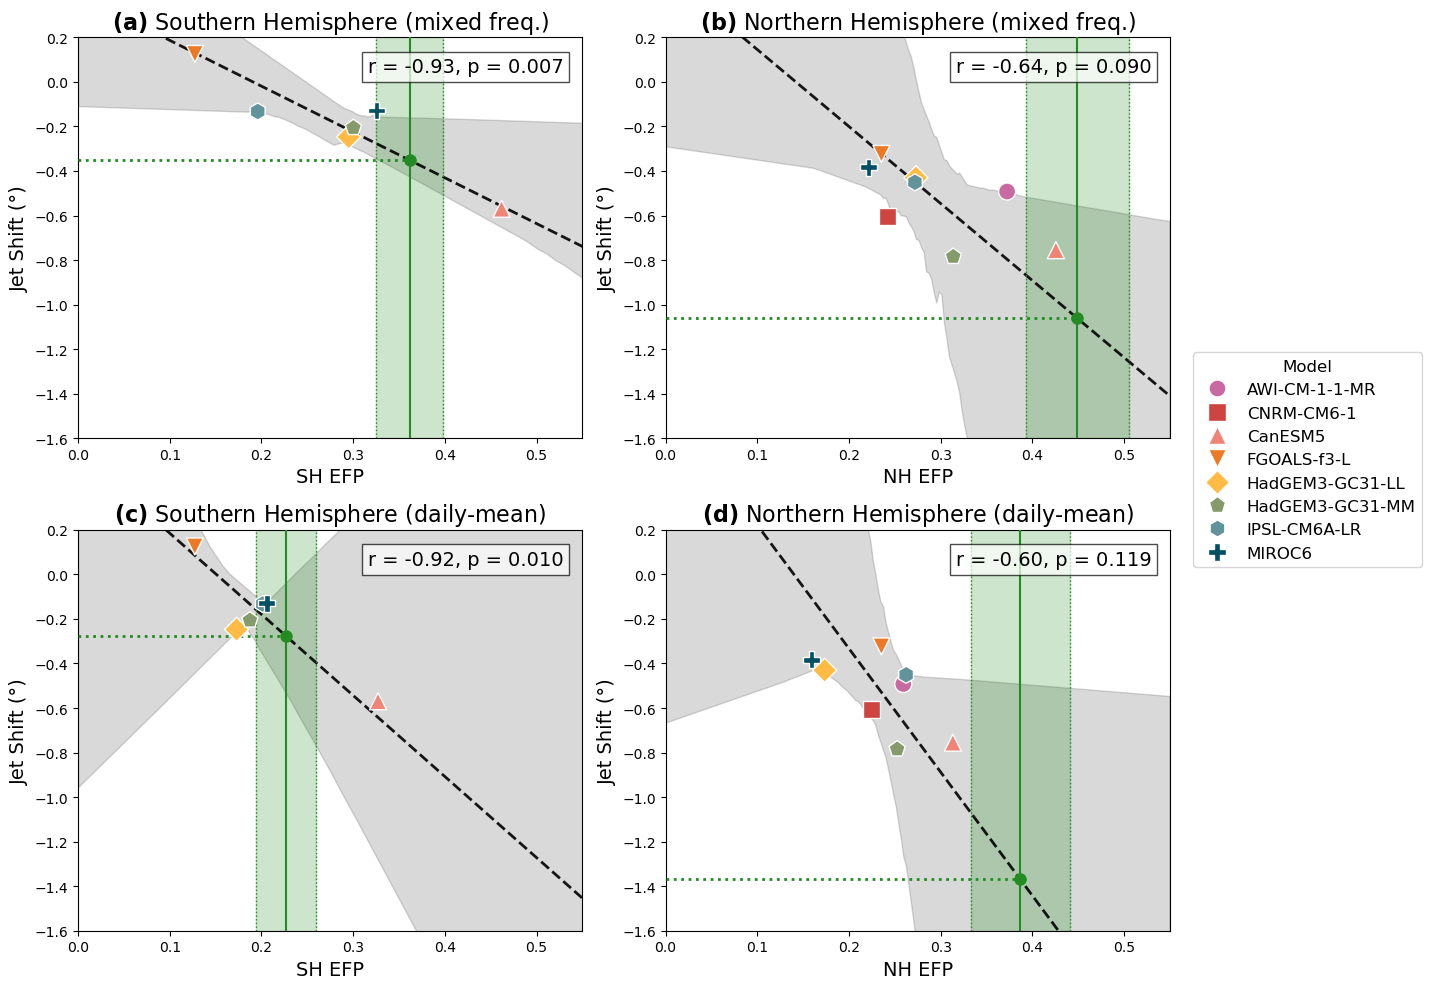

In [28]:
import numpy as np
import scipy.linalg as la
import seaborn as sns
import matplotlib.pyplot as plt

# Your existing setup
obs_efp = {
    'SH': {
        'mixed': jra.loc[1, 'EFP_SH'],
        'daily': jra.loc[0, 'EFP_SH'],
        'mixed_std': jra.loc[1, 'EFP_SH_STD'],
        'daily_std': jra.loc[0, 'EFP_SH_STD']
    },
    'NH': {
        'mixed': jra.loc[1, 'EFP_NH'],
        'daily': jra.loc[0, 'EFP_NH'],
        'mixed_std': jra.loc[1, 'EFP_NH_STD'],
        'daily_std': jra.loc[0, 'EFP_NH_STD']
    }
}

X_LIM = (0, 0.55)
Y_LIM = (-1.6, 0.2)

model_list = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, df in enumerate(dfs):
    for j, (resp, efp_col) in enumerate(zip(responses, efp_cols)):
        ax_idx = i * 2 + j
        ax = axes[ax_idx]

        # --------------------
        # Clean data
        # --------------------
        plot_data = df[[efp_col, resp, 'model']].dropna()
        X = plot_data[efp_col].values
        y = plot_data[resp].values

        # --------------------
        # TLS regression
        # --------------------
        X_aug = np.vstack([X, np.ones(len(X))]).T
        data = np.column_stack([X_aug, y])
        _, _, Vt = la.svd(data, full_matrices=False)
        beta_tls = -Vt[-1, :-1] / Vt[-1, -1]
        beta_0, beta_1 = beta_tls[1], beta_tls[0]

        model_list.append((beta_0, beta_1))

        x_range = np.linspace(X_LIM[0], X_LIM[1], 200)
        y_fit = beta_0 + beta_1 * x_range

        # --------------------
        # TLS bootstrap confidence band
        # --------------------
        nboot = 2000
        y_boot = np.zeros((nboot, len(x_range)))
        rng = np.random.default_rng(42)

        for b in range(nboot):
            idx = rng.integers(0, len(X), len(X))
            Xb = X[idx]
            yb = y[idx]

            try:
                Xb_aug = np.vstack([Xb, np.ones(len(Xb))]).T
                data_b = np.column_stack([Xb_aug, yb])
                _, _, Vtb = la.svd(data_b, full_matrices=False)
                beta_b = -Vtb[-1, :-1] / Vtb[-1, -1]
                b0, b1 = beta_b[1], beta_b[0]
                y_boot[b, :] = b0 + b1 * x_range
            except np.linalg.LinAlgError:
                y_boot[b, :] = np.nan

        y_boot = y_boot[~np.isnan(y_boot).any(axis=1)]
        y_lo = np.percentile(y_boot, 2.5, axis=0)
        y_hi = np.percentile(y_boot, 97.5, axis=0)

        # --------------------
        # Plot TLS CI band + line
        # --------------------
        ax.fill_between(
            x_range, y_lo, y_hi,
            color='k', alpha=0.15, zorder=1
        )

        ax.plot(
            x_range, y_fit,
            'k--', linewidth=2, alpha=0.9, zorder=2
        )

        # --------------------
        # Scatter plot
        # --------------------
        sns.scatterplot(
            data=plot_data,
            x=efp_col,
            y=resp,
            hue='model',
            style='model',
            palette=color_map,
            markers=marker_map,
            s=150,
            ax=ax,
            zorder=4
        )

        handles, labels = ax.get_legend_handles_labels()
        ax.legend_.remove()

        # --------------------
        # Observed value lines
        # --------------------
        hemisphere = 'NH' if j == 1 else 'SH'
        time_res = 'daily' if i == 1 else 'mixed'
        obs_x = obs_efp[hemisphere][time_res]
        obs_std = obs_efp[hemisphere][time_res + '_std']
        obs_y = beta_0 + beta_1 * obs_x

        ax.vlines(obs_x, Y_LIM[0], Y_LIM[1],
                  colors='forestgreen', linewidth=1.5, zorder=3)
        ax.vlines(obs_x - obs_std, Y_LIM[0], Y_LIM[1],
                  colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.vlines(obs_x + obs_std, Y_LIM[0], Y_LIM[1],
                  colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.axvspan(obs_x - obs_std, obs_x + obs_std,
                   color='green', alpha=0.2, zorder=1)
        ax.hlines(obs_y, X_LIM[0], obs_x,
                  colors='forestgreen', linestyles=':',
                  linewidth=2, zorder=3)
        ax.plot(obs_x, obs_y,
                color='forestgreen', marker='o',
                markersize=8, zorder=5)

        # --------------------
        # Annotations & layout
        # --------------------
        dw.add_correlation(ax, plot_data[efp_col], plot_data[resp], x_loc=0.575)

        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_title(f'$\\bf{{{subplots[ax_idx]}}}$ {titles[ax_idx]}', fontsize=16)
        ax.set_ylabel('Jet Shift (°)', fontsize=14)
        ax.set_xlabel('NH EFP' if ax_idx in [1, 3] else 'SH EFP', fontsize=14)

# Shared legend
fig.legend(
    handles,
    efp_df['model'],
    title='Model',
    bbox_to_anchor=(0.85, 0.65),
    loc='upper left',
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


## Ordinary Least Squares

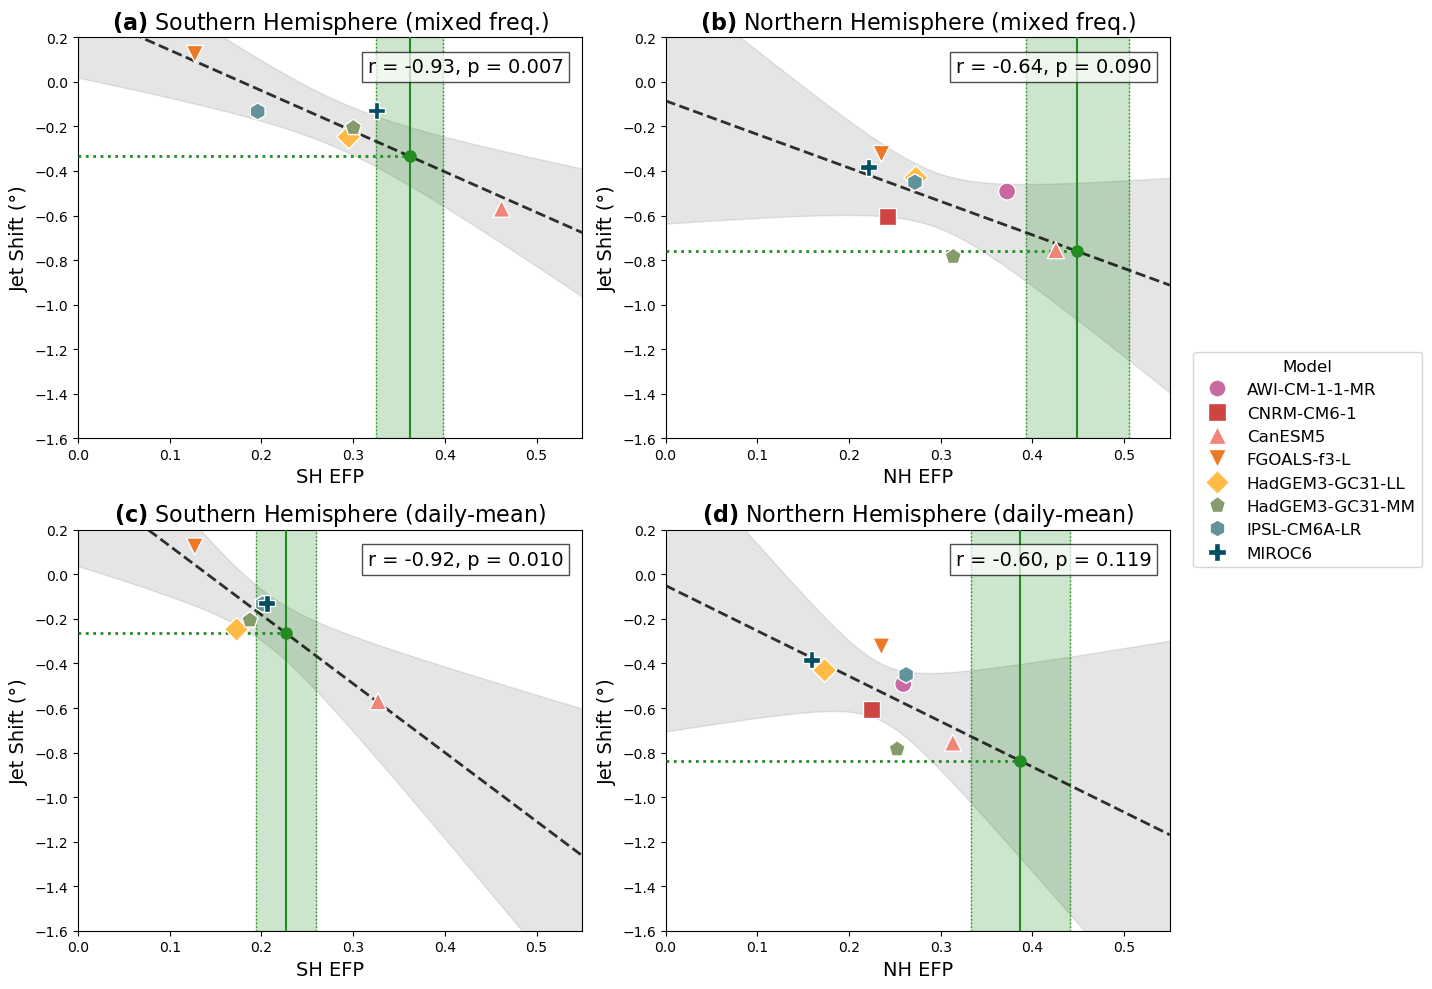

In [14]:
obs_efp = {
    'SH': {
'mixed': jra.loc[1, 'EFP_SH'], 
'daily': jra.loc[0, 'EFP_SH'],
'mixed_std': jra.loc[1, 'EFP_SH_STD'],
'daily_std': jra.loc[0, 'EFP_SH_STD']
    }, 
'NH': {
'mixed': jra.loc[1, 'EFP_NH'], 
'daily': jra.loc[0, 'EFP_NH'],
'mixed_std': jra.loc[1, 'EFP_NH_STD'],
'daily_std': jra.loc[0, 'EFP_NH_STD']
    } 
}

# Axis limits
X_LIM = (0, 0.55)
Y_LIM = (-1.6, 0.2)

model_list = []
# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, df in enumerate(dfs):
    for j, (resp, efp_col) in enumerate(zip(responses, efp_cols)):
        ax_idx = i * 2 + j
        ax = axes[ax_idx]
        
        # Clean data (drop NaNs)
        plot_data = df[[efp_col, resp, 'model']].dropna()
        
        # --- REGRESSION WITH STATSMODELS ---
        X = plot_data[efp_col].values
        y = plot_data[resp].values
        X_with_const = sm.add_constant(X)
        model = sm.OLS(y, X_with_const).fit()
        model_list.append(model)
        
        # Generate regression line and confidence intervals
        x_range = np.linspace(X_LIM[0], X_LIM[1], 100)
        X_pred = sm.add_constant(x_range)
        predictions = model.get_prediction(X_pred)
        pred_summary = predictions.summary_frame(alpha=0.05)
        
        # Plot regression line and CI
        ax.plot(x_range, pred_summary['mean'], 'k--', linewidth=2, alpha=0.8, zorder=2)
        ax.fill_between(
            x_range, 
            pred_summary['mean_ci_lower'], 
            pred_summary['mean_ci_upper'], 
            color='gray', 
            alpha=0.2,
            zorder=1
        )
        
        # Scatter plot with model-specific colors/markers
        sns.scatterplot(
            data=plot_data,
            x=efp_col,
            y=resp,
            hue='model',
            style='model',
            palette=color_map,
            markers=marker_map,
            s=150,
            ax=ax,
            zorder=4
        )
        handles, labels = ax.get_legend_handles_labels()
        ax.legend_.remove()
        
        # --- ADD OBSERVED VALUE LINES ---
        # Determine which hemisphere and time resolution
        hemisphere = 'NH' if j == 1 else 'SH'
        time_res = 'daily' if i == 1 else 'mixed'
        
        # Get observed EFP value and standard deviation
        obs_x = obs_efp[hemisphere][time_res]
        obs_std = obs_efp[hemisphere][time_res + '_std']
        
        # Calculate predicted y value at observed x
        obs_y = model.params[0] + model.params[1] * obs_x
        
        # Draw main vertical line spanning full domain
        ax.vlines(obs_x, Y_LIM[0], Y_LIM[1], colors='forestgreen', linewidth=1.5, zorder=3)
        
        # Draw thinner uncertainty bound lines
        ax.vlines(obs_x - obs_std, Y_LIM[0], Y_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.vlines(obs_x + obs_std, Y_LIM[0], Y_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        
        # Shade the uncertainty region
        ax.axvspan(obs_x - obs_std, obs_x + obs_std, color='green', alpha=0.2, zorder=1)
        
        # Draw horizontal line from regression line to y-axis
        ax.hlines(obs_y, X_LIM[0], obs_x, colors='forestgreen', linestyles=':', linewidth=2, zorder=3)
        
        # Optional: add a marker at the intersection point
        ax.plot(obs_x, obs_y, color='forestgreen', marker='o', markersize=8, zorder=5)
        
        # Add correlation annotation
        dw.add_correlation(ax, plot_data[efp_col], plot_data[resp], x_loc=0.575)
        
        # Set limits and labels
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_title(f'$\\bf{{{subplots[ax_idx]}}}$ {titles[ax_idx]}', fontsize=16)
        ax.set_ylabel('Jet Shift (°)', fontsize=14)
        
        # Hemisphere-specific x-labels
        if ax_idx in [1, 3]:
            ax.set_xlabel('NH EFP', fontsize=14)
        else:
            ax.set_xlabel('SH EFP', fontsize=14)

# Add shared legend
fig.legend(
    handles, 
    efp_df['model'], 
    title='Model', 
    bbox_to_anchor=(0.85, 0.65), 
    loc='upper left',
    fontsize=12, 
    title_fontsize=12
)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Uncertainty lines

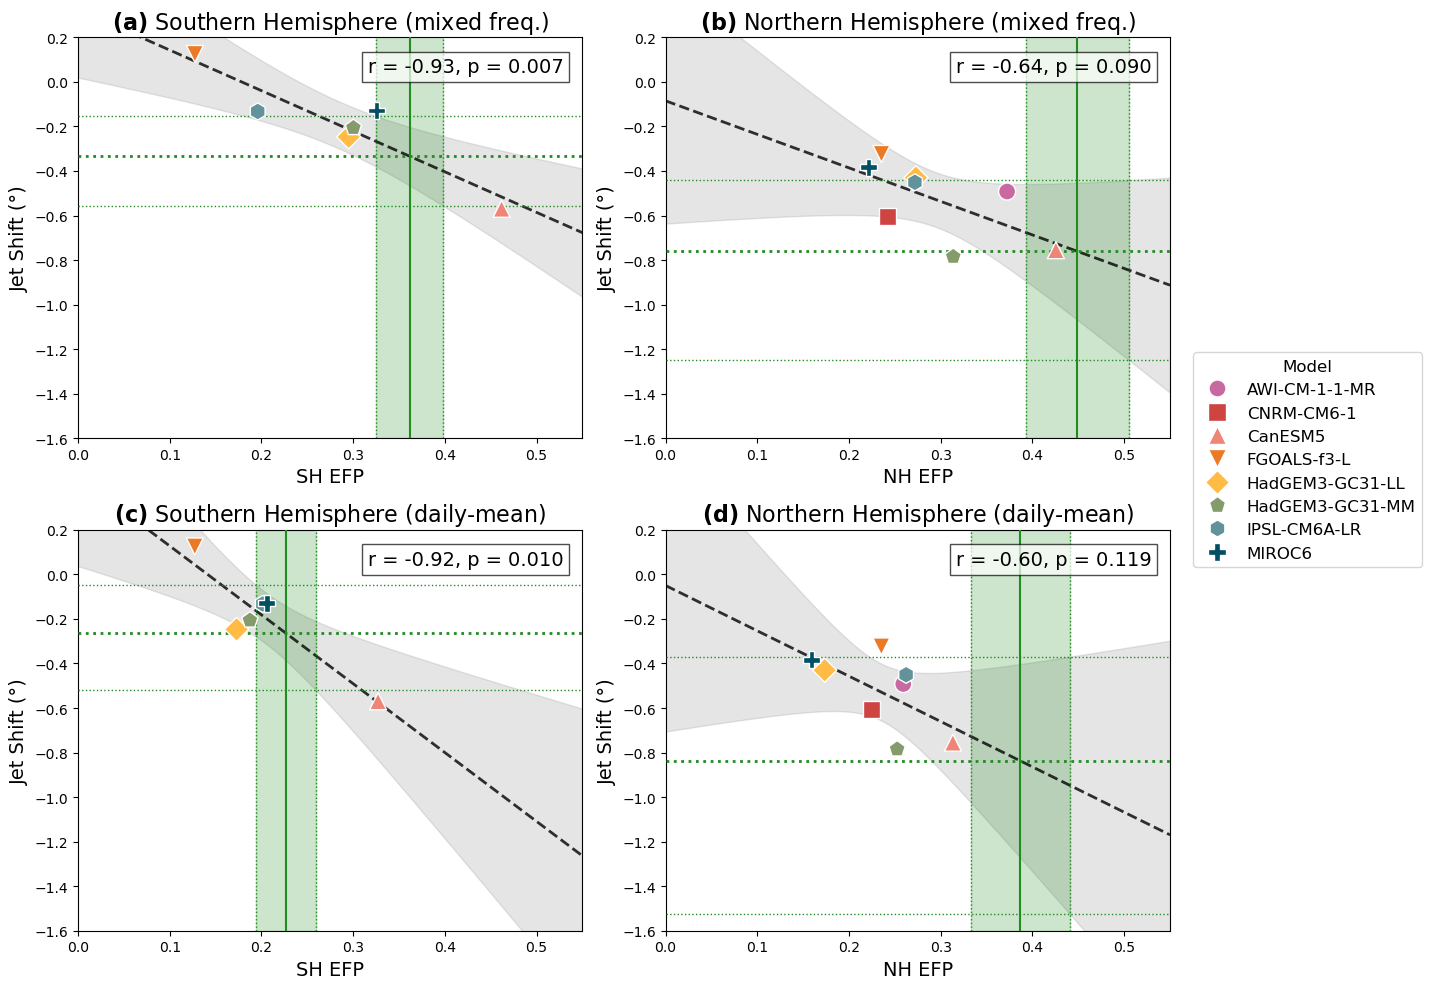

In [15]:
obs_efp = {
    'SH': {
'mixed': jra.loc[1, 'EFP_SH'], 
'daily': jra.loc[0, 'EFP_SH'],
'mixed_std': jra.loc[1, 'EFP_SH_STD'],
'daily_std': jra.loc[0, 'EFP_SH_STD']
    }, 
'NH': {
'mixed': jra.loc[1, 'EFP_NH'], 
'daily': jra.loc[0, 'EFP_NH'],
'mixed_std': jra.loc[1, 'EFP_NH_STD'],
'daily_std': jra.loc[0, 'EFP_NH_STD']
    } 
}

# Axis limits
X_LIM = (0, 0.55)
Y_LIM = (-1.6, 0.2)

model_list = []
# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, df in enumerate(dfs):
    for j, (resp, efp_col) in enumerate(zip(responses, efp_cols)):
        ax_idx = i * 2 + j
        ax = axes[ax_idx]
        
        # Clean data (drop NaNs)
        plot_data = df[[efp_col, resp, 'model']].dropna()
        
        # --- REGRESSION WITH STATSMODELS ---
        X = plot_data[efp_col].values
        y = plot_data[resp].values
        X_with_const = sm.add_constant(X)
        model = sm.OLS(y, X_with_const).fit()
        model_list.append(model)
        
        # Generate regression line and confidence intervals
        x_range = np.linspace(X_LIM[0], X_LIM[1], 100)
        X_pred = sm.add_constant(x_range)
        predictions = model.get_prediction(X_pred)
        pred_summary = predictions.summary_frame(alpha=0.05)
        
        # Plot regression line and CI
        ax.plot(x_range, pred_summary['mean'], 'k--', linewidth=2, alpha=0.8, zorder=2)
        ax.fill_between(
            x_range, 
            pred_summary['mean_ci_lower'], 
            pred_summary['mean_ci_upper'], 
            color='gray', 
            alpha=0.2,
            zorder=1
        )
        
        # Scatter plot with model-specific colors/markers
        sns.scatterplot(
            data=plot_data,
            x=efp_col,
            y=resp,
            hue='model',
            style='model',
            palette=color_map,
            markers=marker_map,
            s=150,
            ax=ax,
            zorder=4
        )
        handles, labels = ax.get_legend_handles_labels()
        ax.legend_.remove()
        
        # --- ADD OBSERVED VALUE LINES ---
        # Determine which hemisphere and time resolution
        hemisphere = 'NH' if j == 1 else 'SH'
        time_res = 'daily' if i == 1 else 'mixed'
        
        # Get observed EFP value and standard deviation
        obs_x = obs_efp[hemisphere][time_res]
        obs_std = obs_efp[hemisphere][time_res + '_std']
        
        # Calculate predicted y value at observed x
        obs_y = model.params[0] + model.params[1] * obs_x
        
        # Draw main vertical line spanning full domain
        ax.vlines(obs_x, Y_LIM[0], Y_LIM[1], colors='forestgreen', linewidth=1.5, zorder=3)
        
        # Draw thinner uncertainty bound lines
        ax.vlines(obs_x - obs_std, Y_LIM[0], Y_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.vlines(obs_x + obs_std, Y_LIM[0], Y_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        
        # Shade the uncertainty region
        ax.axvspan(obs_x - obs_std, obs_x + obs_std, color='green', alpha=0.2, zorder=1)
        
        # Calculate CI bounds at the uncertainty edges
        # Interpolate CI values at obs_x - obs_std and obs_x + obs_std
        ci_lower_at_lower = np.interp(obs_x - obs_std, x_range, pred_summary['mean_ci_lower'])
        ci_upper_at_lower = np.interp(obs_x - obs_std, x_range, pred_summary['mean_ci_upper'])
        ci_lower_at_upper = np.interp(obs_x + obs_std, x_range, pred_summary['mean_ci_lower'])
        ci_upper_at_upper = np.interp(obs_x + obs_std, x_range, pred_summary['mean_ci_upper'])
        
        # Find the largest range (min and max y-values across both SD bounds)
        y_min = min(ci_lower_at_lower, ci_lower_at_upper)
        y_max = max(ci_upper_at_lower, ci_upper_at_upper)
        
        # Draw horizontal lines at these extreme y-values spanning full domain
        ax.hlines(y_min, X_LIM[0], X_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        ax.hlines(y_max, X_LIM[0], X_LIM[1], colors='forestgreen', linestyles=':', linewidth=1, zorder=3)
        
        # Draw horizontal line from regression line spanning full domain
        ax.hlines(obs_y, X_LIM[0], X_LIM[1], colors='forestgreen', linestyles=':', linewidth=2, zorder=3)
        
        # Optional: add a marker at the intersection point
        # ax.plot(obs_x, obs_y, color='forestgreen', marker='o', markersize=8, zorder=5)
        
        # Add correlation annotation
        dw.add_correlation(ax, plot_data[efp_col], plot_data[resp], x_loc=0.575)
        
        # Set limits and labels
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.set_title(f'$\\bf{{{subplots[ax_idx]}}}$ {titles[ax_idx]}', fontsize=16)
        ax.set_ylabel('Jet Shift (°)', fontsize=14)
        
        # Hemisphere-specific x-labels
        if ax_idx in [1, 3]:
            ax.set_xlabel('NH EFP', fontsize=14)
        else:
            ax.set_xlabel('SH EFP', fontsize=14)

# Add shared legend
fig.legend(
    handles, 
    efp_df['model'], 
    title='Model', 
    bbox_to_anchor=(0.85, 0.65), 
    loc='upper left',
    fontsize=12, 
    title_fontsize=12
)
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig('./plots/emergent_constraint_fig6.png', dpi=300)
plt.show()

### Test Normality of Residuals:

Assumption required to use t-distribution test

In [16]:
# import matplotlib.pyplot as plt
# import scipy.stats as stats
# # from scipy import stats

# for model in model_list:

#     # After fitting your model
#     residuals = model.resid

#     # Shapiro-Wilk test
#     statistic, p_value = stats.shapiro(residuals)

#     print(f"Shapiro-Wilk Test:")
#     print(f"  Statistic: {statistic:.4f}")
#     print(f"  P-value: {p_value:.4f}")

#     if p_value > 0.05:
#         print("  ✓ Residuals appear normally distributed (fail to reject H0)")
#     else:
#         print("  ✗ Residuals may not be normally distributed (reject H0)")

#     # Create QQ plot
#     fig, ax = plt.subplots(figsize=(8, 6))
#     stats.probplot(residuals, dist="norm", plot=ax)
#     ax.set_title('Normal Q-Q Plot', fontsize=14)
#     plt.tight_layout()
#     plt.show()



# Original-ish plots

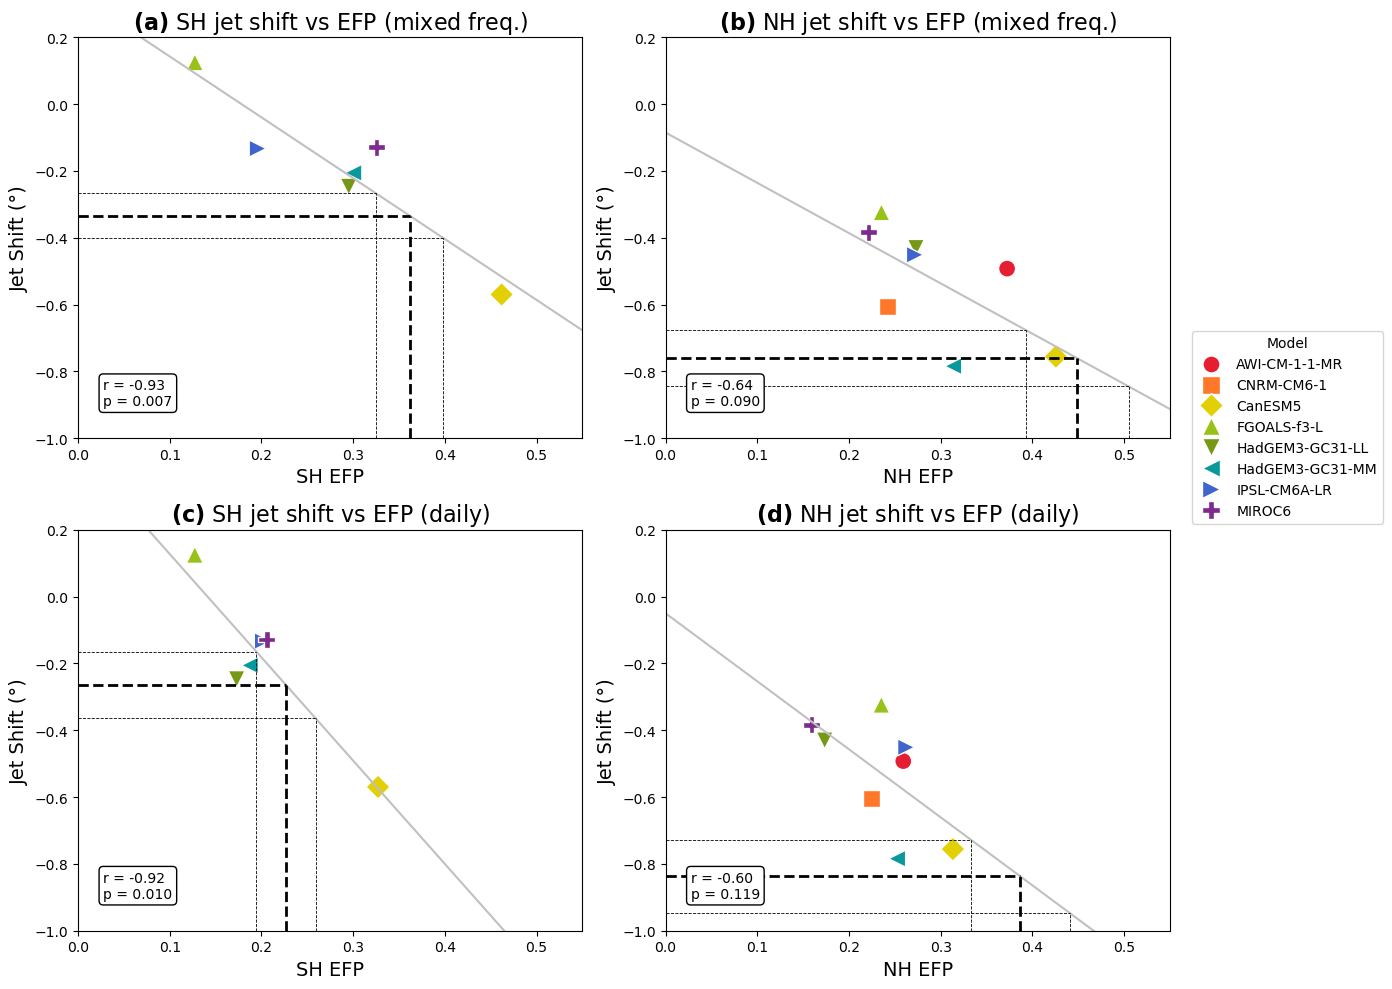

In [17]:
# DataFrames and plot settings
dfs = [og_cut, efp]
responses = ['SH_response', 'NH_response']
efp_cols = ['efp_sh', 'efp_nh']
titles = ['SH jet shift vs EFP (mixed freq.)', 'NH jet shift vs EFP (mixed freq.)', 
          'SH jet shift vs EFP (daily)', 'NH jet shift vs EFP (daily)']
subplots = ['(a)', '(b)', '(c)', '(d)']

# Load colormap from pypalettes
cmap = load_cmap("Rainbow")

# Generate a unique set of models
all_models = sorted(set(og_cut['model']).union(set(efp['model'])))

# Colors (already done)
colors = [cmap(i / (len(all_models) - 1)) for i in range(len(all_models))]
palette = dict(zip(all_models, colors))

# Create a consistent marker mapping
marker_styles = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X', '*']  # extend if needed
markers = dict(zip(all_models, marker_styles * ((len(all_models) // len(marker_styles)) + 1)))

# Value at which to project onto regression line
x_val = np.array([jra.loc[1, 'EFP_SH'], jra.loc[1, 'EFP_NH'],       # jra55_sh_6h, jra55_nh_6h
                  jra.loc[0, 'EFP_SH'], jra.loc[0, 'EFP_NH']])      # jra55_sh_day, jra55_nh_day

x_val_hi = np.array([jra.loc[1, 'EFP_SH'] + jra.loc[1, 'EFP_SH_STD'], 
                     jra.loc[1, 'EFP_NH'] + jra.loc[1, 'EFP_NH_STD'],    
                     jra.loc[0, 'EFP_SH'] + jra.loc[0, 'EFP_SH_STD'], 
                     jra.loc[0, 'EFP_NH'] + jra.loc[0, 'EFP_NH_STD']])      

x_val_lo = np.array([jra.loc[1, 'EFP_SH'] - jra.loc[1, 'EFP_SH_STD'], 
                     jra.loc[1, 'EFP_NH'] - jra.loc[1, 'EFP_NH_STD'],    
                     jra.loc[0, 'EFP_SH'] - jra.loc[0, 'EFP_SH_STD'], 
                     jra.loc[0, 'EFP_NH'] - jra.loc[0, 'EFP_NH_STD']])      

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, df in enumerate(dfs):
    for j, (resp, efp_col) in enumerate(zip(responses, efp_cols)):

        ax_idx = i*2 + j
        ax = axes[ax_idx]
        
        # Mask to drop NaNs for correlation
        mask = df[[efp_col, resp]].dropna()
        r, p = pearsonr(mask[efp_col], mask[resp])
        
        # Scatter plot
        sns.scatterplot(
            data=df,
            x=efp_col,
            y=resp,
            hue='model',
            style='model',
            palette=palette,
            markers=markers,
            s=150,
            ax=ax
        )
        
        # Get current axis limits
        ax.set_xlim(0, 0.55)
        ax.set_ylim(-1.0, 0.2)
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()

        # Fit regression line using numpy
        if len(mask) > 1:  # only fit if there are enough points
            coef = np.polyfit(mask[efp_col], mask[resp], 1)  # slope, intercept
            poly1d_fn = np.poly1d(coef)

            # Plot regression line across axis limits
            ax.plot([x_min, x_max],
                    [poly1d_fn(x_min), poly1d_fn(x_max)],
                    color="silver", linestyle="-")

            # Projection for x_val (black)
            y_val = poly1d_fn(x_val[ax_idx])
            if y_min <= y_val <= y_max:
                ax.plot([x_val[ax_idx], x_val[ax_idx]], [y_min, y_val], color="black", linestyle="--", linewidth=2)
                ax.plot([x_min, x_val[ax_idx]], [y_val, y_val], color="black", linestyle="--", linewidth=2)
                # ax.scatter([x_val[ax_idx]], [y_val], color="black", zorder=5)

            # Projection for x_val_hi (red)
            y_val_hi = poly1d_fn(x_val_hi[ax_idx])
            if y_min <= y_val_hi <= y_max:
                ax.plot([x_val_hi[ax_idx], x_val_hi[ax_idx]], [y_min, y_val_hi], color="k", linestyle="--", linewidth=0.6)
                ax.plot([x_min, x_val_hi[ax_idx]], [y_val_hi, y_val_hi], color="k", linestyle="--", linewidth=0.6)
                # ax.scatter([x_val_hi[ax_idx]], [y_val_hi], color="red", zorder=5)

            # Projection for x_val_lo (blue)
            y_val_lo = poly1d_fn(x_val_lo[ax_idx])
            if y_min <= y_val_lo <= y_max:
                ax.plot([x_val_lo[ax_idx], x_val_lo[ax_idx]], [y_min, y_val_lo], color="k", linestyle="--", linewidth=0.6)
                ax.plot([x_min, x_val_lo[ax_idx]], [y_val_lo, y_val_lo], color="k", linestyle="--", linewidth=0.6)
                # ax.scatter([x_val_lo[ax_idx]], [y_val_lo], color="blue", zorder=5)
        
        ax.set_title(f'$\\bf{subplots[ax_idx]}$ '+ titles[ax_idx], fontsize=16)
        ax.text(
            0.05, 0.15,
            f"r = {r:.2f}\np = {p:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white")
        )
        ax.get_legend().remove()  # remove individual legends
        
        ax.set_ylabel('Jet Shift (°)', fontsize=14)
        
        if ax_idx in [1,3]:  # Right column
            ax.set_xlabel('NH EFP', fontsize=14)
        else:
            ax.set_xlabel('SH EFP', fontsize=14)

# Add a single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:len(all_models)], all_models, title='Model', bbox_to_anchor=(0.85, 0.67), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


## Seaborn method

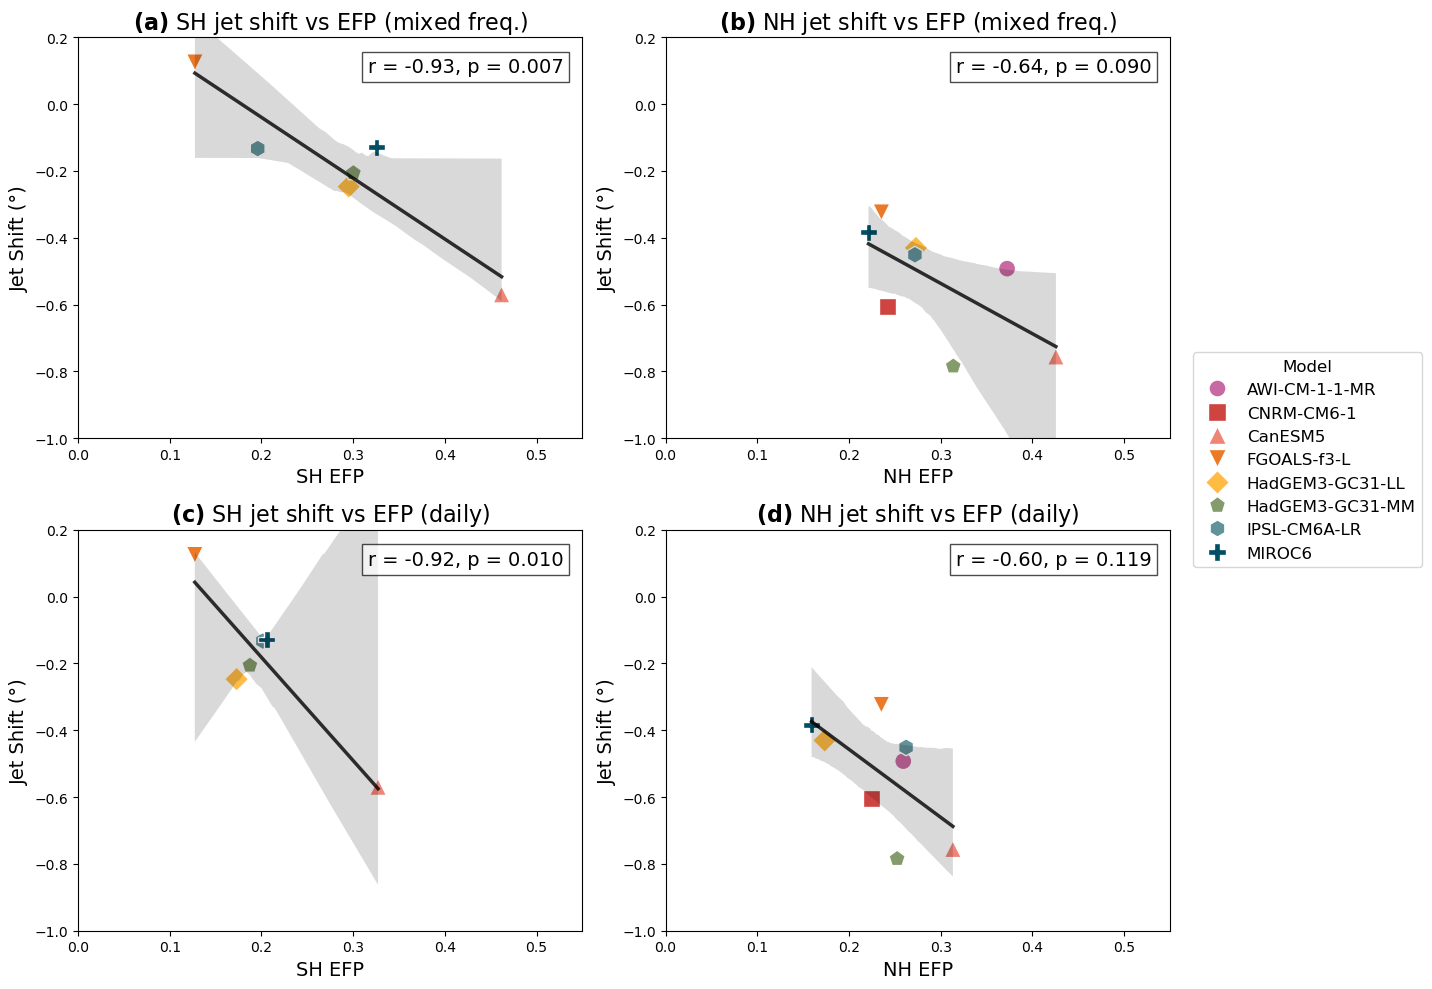

In [18]:
# DataFrames and plot settings
dfs = [og_cut, efp]
responses = ['SH_response', 'NH_response']
efp_cols = ['efp_sh', 'efp_nh']
titles = ['SH jet shift vs EFP (mixed freq.)', 'NH jet shift vs EFP (mixed freq.)', 
          'SH jet shift vs EFP (daily)', 'NH jet shift vs EFP (daily)']
subplots = ['(a)', '(b)', '(c)', '(d)']  

# Create a mapping dictionary for quick lookup
color_map = dict(zip(efp_df['model'], efp_df['color']))
marker_map = dict(zip(efp_df['model'], efp_df['marker'])) 

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, df in enumerate(dfs):
    for j, (resp, efp_col) in enumerate(zip(responses, efp_cols)):

        ax_idx = i*2 + j
        ax = axes[ax_idx]
        
        # Mask to drop NaNs for correlation
        mask = df[[efp_col, resp]].dropna()
        dw.add_correlation(ax, mask[efp_col], mask[resp], x_loc=0.575)
        
        # Scatter plot
        sns.scatterplot(
            data=df,
            x=efp_col,
            y=resp,
            hue='model',
            style='model',
            palette=color_map,
            markers=marker_map,
            s=150,
            ax=ax
        )
        # Replace the regplot section with:
        sns.regplot(
            data=df,
            x=efp_col,
            y=resp,
            scatter=False,
            color='black',  # Or '#333333' for dark gray
            line_kws={'linewidth': 2.5, 'linestyle': '-', 'alpha': 0.8},
            ci=95,  # 95% confidence interval (default)
            ax=ax
        )
        
        # Get current axis limits
        ax.set_xlim(0, 0.55)
        ax.set_ylim(-1.0, 0.2)
        
        ax.set_title(f'$\\bf{subplots[ax_idx]}$ '+ titles[ax_idx], fontsize=16)
        ax.get_legend().remove()  # remove individual legends
        
        ax.set_ylabel('Jet Shift (°)', fontsize=14)
        
        if ax_idx in [1,3]:  # Right column
            ax.set_xlabel('NH EFP', fontsize=14)
        else:
            ax.set_xlabel('SH EFP', fontsize=14)

# Add a single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:len(efp_df['model'])], efp_df['model'], 
           title='Model', bbox_to_anchor=(0.85, 0.65), loc='upper left',
           fontsize=12, title_fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Claude stats explanation

[link here](https://claude.ai/chat/0f2de037-5f7e-480c-b95c-a775f3e3e796)

I'll walk you through the regression and confidence interval calculations in your code, and provide proper citations.Excellent question! Let me walk through the statistical methods used in your code step-by-step with proper citations.

## 1. **Ordinary Least Squares (OLS) Regression**

Your code uses OLS regression via `statsmodels.OLS`. OLS minimizes the sum of squared residuals to find the best-fitting line through your data.

**The Model:**
For simple linear regression, you're fitting:
$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$$

where $y_i$ is jet shift, $x_i$ is EFP, $\beta_0$ is the intercept, $\beta_1$ is the slope, and $\varepsilon_i$ is the error term.

**The OLS Estimator:**
The parameter estimates are found by minimizing the residual sum of squares:
$$\text{RSS} = \sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i)^2$$

This yields the estimates:
$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = \frac{s_{xy}}{s_x^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

where $s_{xy}$ is the sample covariance and $s_x^2$ is the sample variance of x.

**Key References:**
- Wooldridge, J.M. (2013). *Introductory Econometrics: A Modern Approach* (5th ed.). Cengage Learning. Chapters 2-4.
- Wikipedia contributors. (2025). "Ordinary least squares." *Wikipedia*. https://en.wikipedia.org/wiki/Ordinary_least_squares

---

## 2. **Confidence Intervals for the Mean Response**

The confidence intervals you're plotting represent uncertainty in the **mean** response (the regression line itself), not individual predictions.

**The Formula:**
The 95% confidence interval for the mean response at predictor value $x_h$ is:

$$\hat{y}_h \pm t_{(\alpha/2, n-2)} \times \text{SE}(\hat{y}_h)$$

where:

$$\text{SE}(\hat{y}_h) = \sqrt{\text{MSE} \times \left(\frac{1}{n} + \frac{(x_h - \bar{x})^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}\right)}$$

**Components:**
- $\hat{y}_h$ = predicted value at $x_h$
- $t_{(\alpha/2, n-2)}$ = critical value from Student's t-distribution with $n-2$ degrees of freedom
- MSE = Mean Square Error = $\frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{n-2}$
- $\alpha = 0.05$ for 95% confidence

**Key Insight:** The standard error is smallest at $\bar{x}$ (the mean of your EFP values) and increases as you move away from the mean. This is why confidence intervals have that characteristic "hourglass" shape.

**Key References:**
- Penn State. "Confidence Interval for the Mean Response." STAT 462. https://online.stat.psu.edu/stat462/node/126/
- Penn State. "Prediction Interval for a New Response." STAT 501. https://online.stat.psu.edu/stat501/lesson/3/3.3

---

## 3. **How Statsmodels Computes This**

Your code sequence:
```python
X_with_const = sm.add_constant(X)  # Adds column of 1s for intercept
model = sm.OLS(y, X_with_const).fit()  # Fits the model
predictions = model.get_prediction(X_pred)  # Gets predictions with uncertainty
pred_summary = predictions.summary_frame(alpha=0.05)  # 95% CI
```

The `get_prediction()` method computes:
- The predicted mean: `pred_summary['mean']`
- Lower CI bound: `pred_summary['mean_ci_lower']`
- Upper CI bound: `pred_summary['mean_ci_upper']`

These intervals are for the **mean response** (where the true regression line lies), using the t-distribution as described above.

**Key References:**
- Statsmodels developers. "OLSResults.get_prediction." *Statsmodels Documentation*. https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_prediction.html
- Seabold, S., & Perktold, J. (2010). "Statsmodels: Econometric and statistical modeling with Python." *Proceedings of the 9th Python in Science Conference*.

---

## 4. **Confidence Interval vs Prediction Interval**

It's worth noting that you're computing **confidence intervals** (CI), not **prediction intervals** (PI). The distinction:

- **Confidence Interval:** Uncertainty about where the *mean* lies. Answers: "Where is the true regression line?"
  
- **Prediction Interval:** Uncertainty about where a *new individual observation* will fall. Always wider because it includes both:
  - Uncertainty in the mean (like CI)
  - Plus natural scatter in individual observations

The PI formula would be:
$$\hat{y}_h \pm t_{(\alpha/2, n-2)} \times \sqrt{\text{MSE} \times \left(1 + \frac{1}{n} + \frac{(x_h - \bar{x})^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}\right)}$$

Note the extra "1+" inside the square root.

**Key References:**
- DataCamp. (2024). "Confidence vs Prediction Intervals: Understanding the Difference." https://www.datacamp.com/blog/confidence-intervals-vs-prediction-intervals
- Casual Inference. (2020). "Understanding the difference between prediction and confidence intervals for linear models in Python." https://lmc2179.github.io/posts/confidence_prediction.html

---

## 5. **Assumptions Required**

For these CIs to be valid, OLS requires:
1. **Linearity:** True relationship is linear
2. **Independence:** Observations are independent
3. **Homoscedasticity:** Constant error variance
4. **Normality:** Errors are approximately normally distributed (for exact t-intervals; less critical with large samples)
5. **No multicollinearity** (if you had multiple predictors)

The t-distribution accounts for parameter estimation uncertainty. With large samples, the t-distribution approaches the normal distribution.

---

This approach is standard in climate science for analyzing model-observation relationships. Your visualization effectively shows both the best estimate (regression line) and the statistical uncertainty (shaded CI) in the relationship between EFP and jet shift!